In [1]:
# ==============================================================================================================================
#                               Python DA Assignment 2 - Data Visualization
# ==============================================================================================================================


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=sns.load_dataset("taxis")
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [4]:
df.shape

(6433, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [7]:
df.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


In [8]:
df.isnull().sum()

pickup              0
dropoff             0
passengers          0
distance            0
fare                0
tip                 0
tolls               0
total               0
color               0
payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

In [9]:
df.isnull().sum() [df.isnull().sum() > 0]

payment            44
pickup_zone        26
dropoff_zone       45
pickup_borough     26
dropoff_borough    45
dtype: int64

In [10]:
cols = [
    "payment",
    "pickup_zone",
    "dropoff_zone",
    "pickup_borough",
    "dropoff_borough"
]

for col in cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [11]:
df.isnull().sum()

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64

In [12]:
df["pickup"] = pd.to_datetime(df["pickup"])

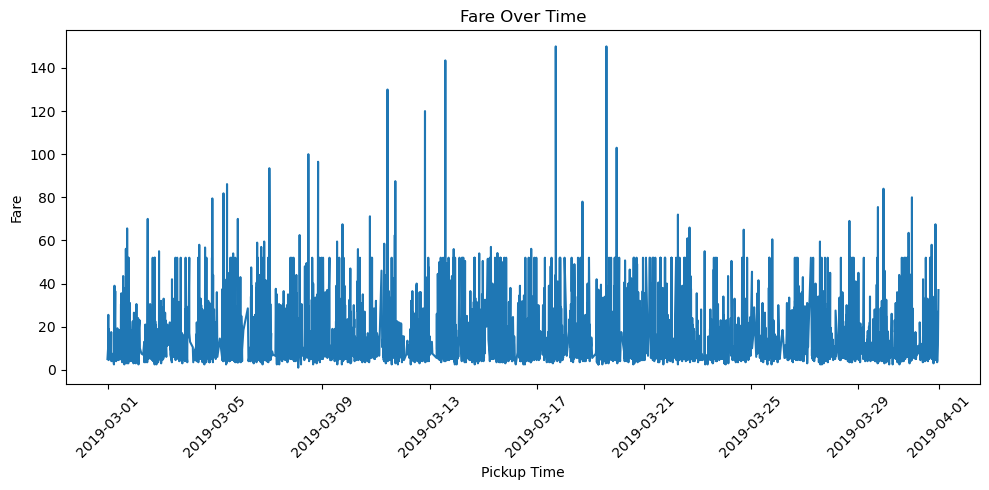

In [13]:
# ★ Line Chart

line_df = df.sort_values("pickup")

plt.figure(figsize=(10, 5))

plt.plot(line_df["pickup"], line_df["fare"])

plt.title("Fare Over Time")
plt.xlabel("Pickup Time")
plt.ylabel("Fare")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

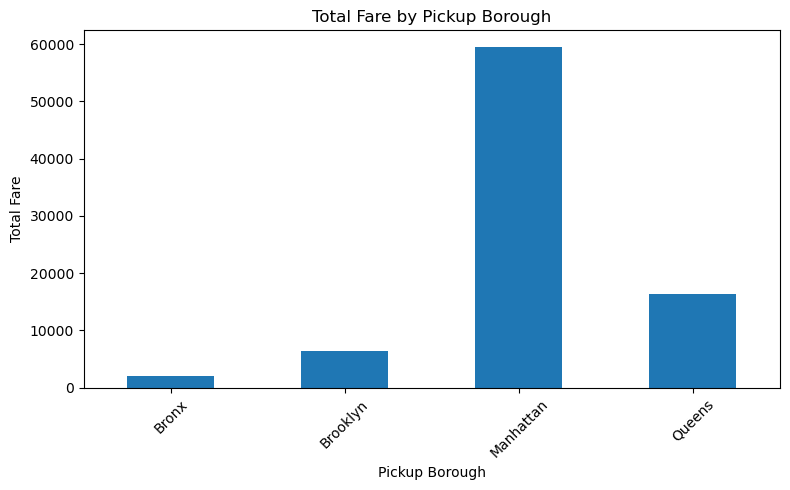

In [14]:
# ★ Bar Chart

borough_fare = df.groupby("pickup_borough")["fare"].sum()

plt.figure(figsize=(8, 5))

borough_fare.plot(kind="bar")

plt.title("Total Fare by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Total Fare")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

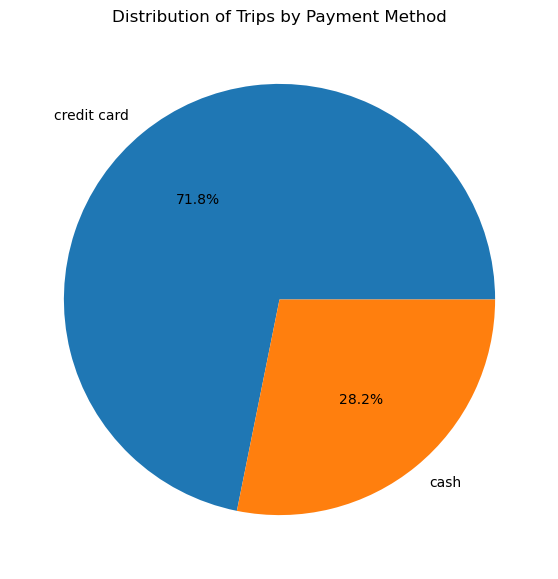

In [15]:
# ★ Pie Chart

payment_counts = df["payment"].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%"
)

plt.title("Distribution of Trips by Payment Method")

plt.show()

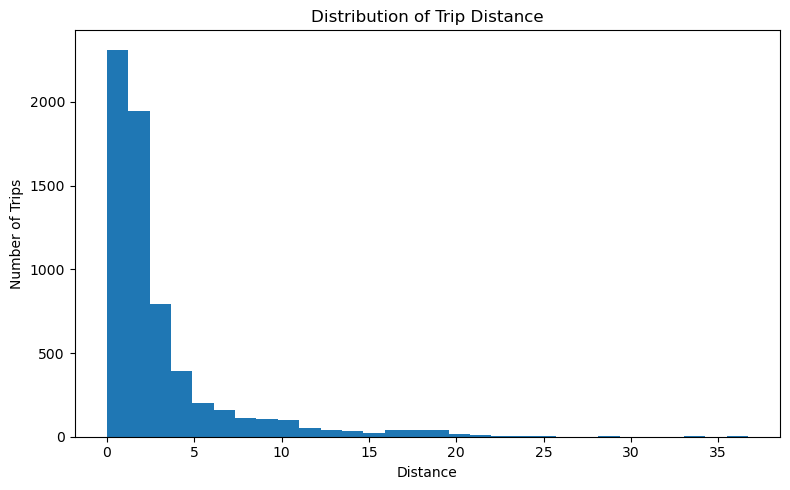

In [16]:
# ★ Histogram

plt.figure(figsize=(8, 5))

plt.hist(df["distance"], bins=30)

plt.title("Distribution of Trip Distance")
plt.xlabel("Distance")
plt.ylabel("Number of Trips")

plt.tight_layout()
plt.show()

<Figure size 900x500 with 0 Axes>

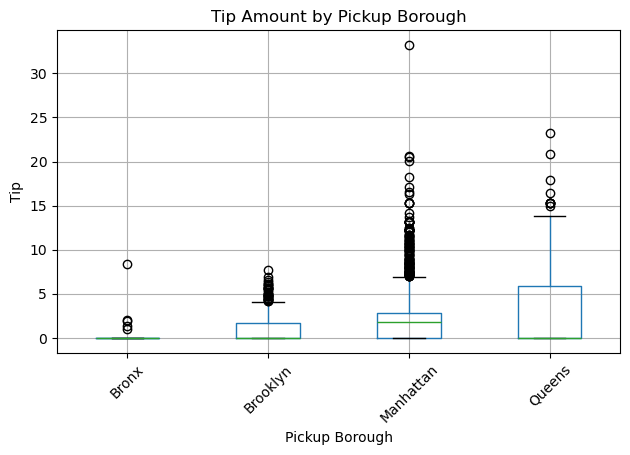

In [17]:
# ★ Box Plot

plt.figure(figsize=(9, 5))

df.boxplot(column="tip", by="pickup_borough")

plt.title("Tip Amount by Pickup Borough")
plt.suptitle("")
plt.xlabel("Pickup Borough")
plt.ylabel("Tip")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

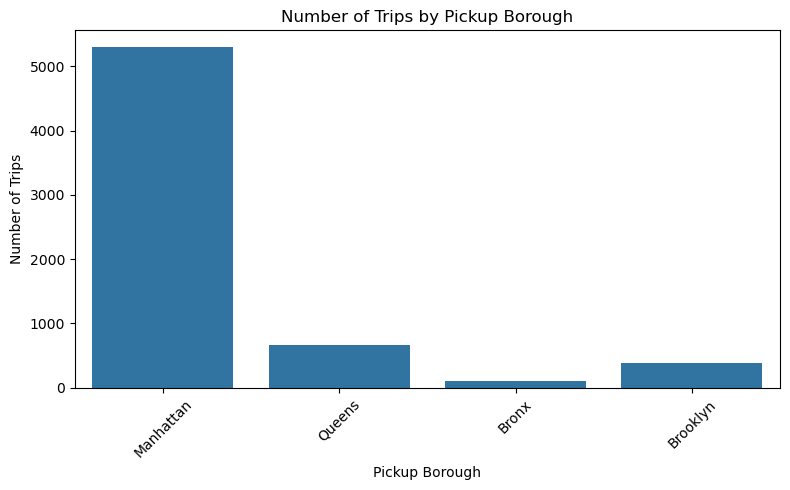

In [18]:
#                           Visualizations using Seaborn:
#-----------------------------------------------------------------------------------------------

#★ Count Plot

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="pickup_borough")

plt.title("Number of Trips by Pickup Borough")
plt.xlabel("Pickup Borough")
plt.ylabel("Number of Trips")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

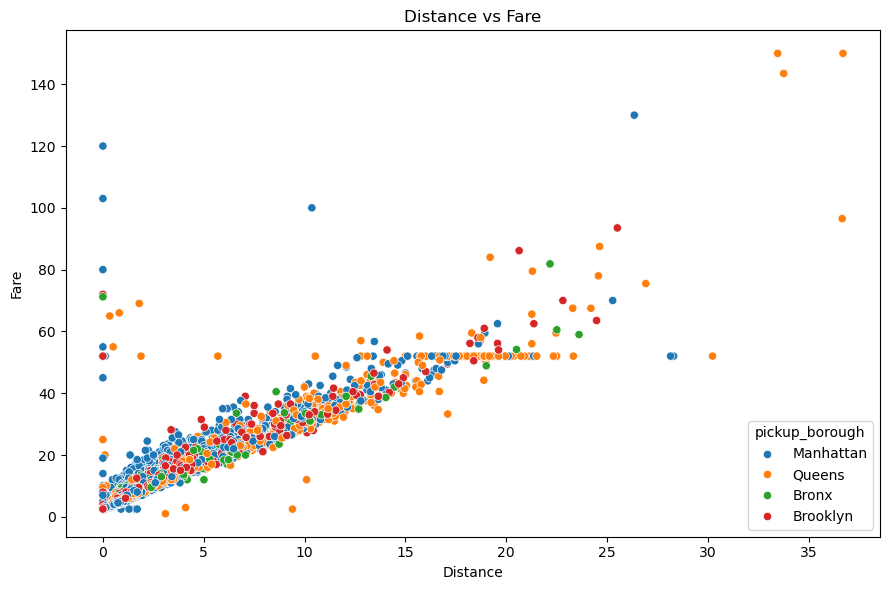

In [19]:
# ★ Scatter Plot

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="distance",
    y="fare",
    hue="pickup_borough"
)

plt.title("Distance vs Fare")
plt.xlabel("Distance")
plt.ylabel("Fare")

plt.tight_layout()
plt.show()

In [20]:
# Correlation Matrix

corr_cols = [
    "distance",
    "fare",
    "tip",
    "tolls",
    "total"
]

correlation_matrix = df[corr_cols].corr()

correlation_matrix

,distance,fare,tip,tolls,total
distance,1.000000,0.920108,0.452589,0.635267,0.904676
fare,0.920108,1.000000,0.488612,0.609307,0.974358
tip,0.452589,0.488612,1.000000,0.413619,0.646186
tolls,0.635267,0.609307,0.413619,1.000000,0.683142
total,0.904676,0.974358,0.646186,0.683142,1.000000


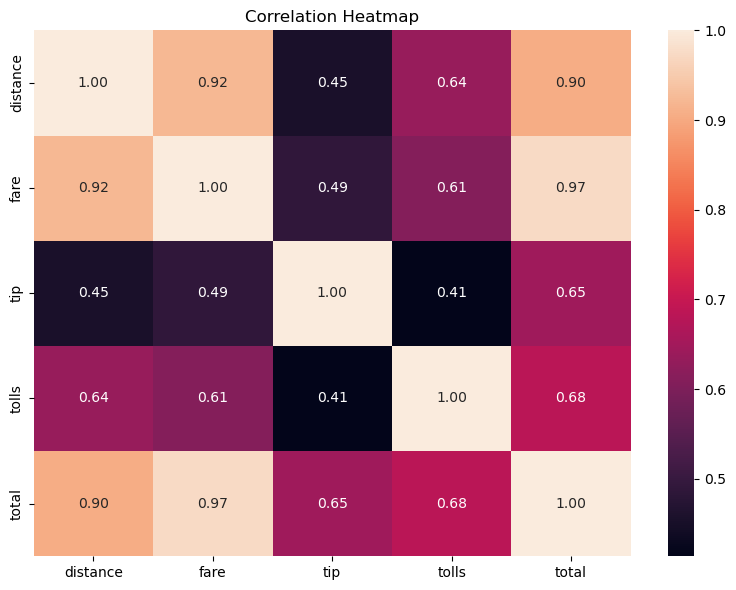

In [21]:
# ★ Heatmap

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [22]:
# Prepare Data for Pair Plot

pair_df = df[
    ["distance", "fare", "tip", "total", "pickup_zone"]
].dropna()

pair_df = pair_df.sample(
    n=min(1000, len(pair_df)),
    random_state=42
)

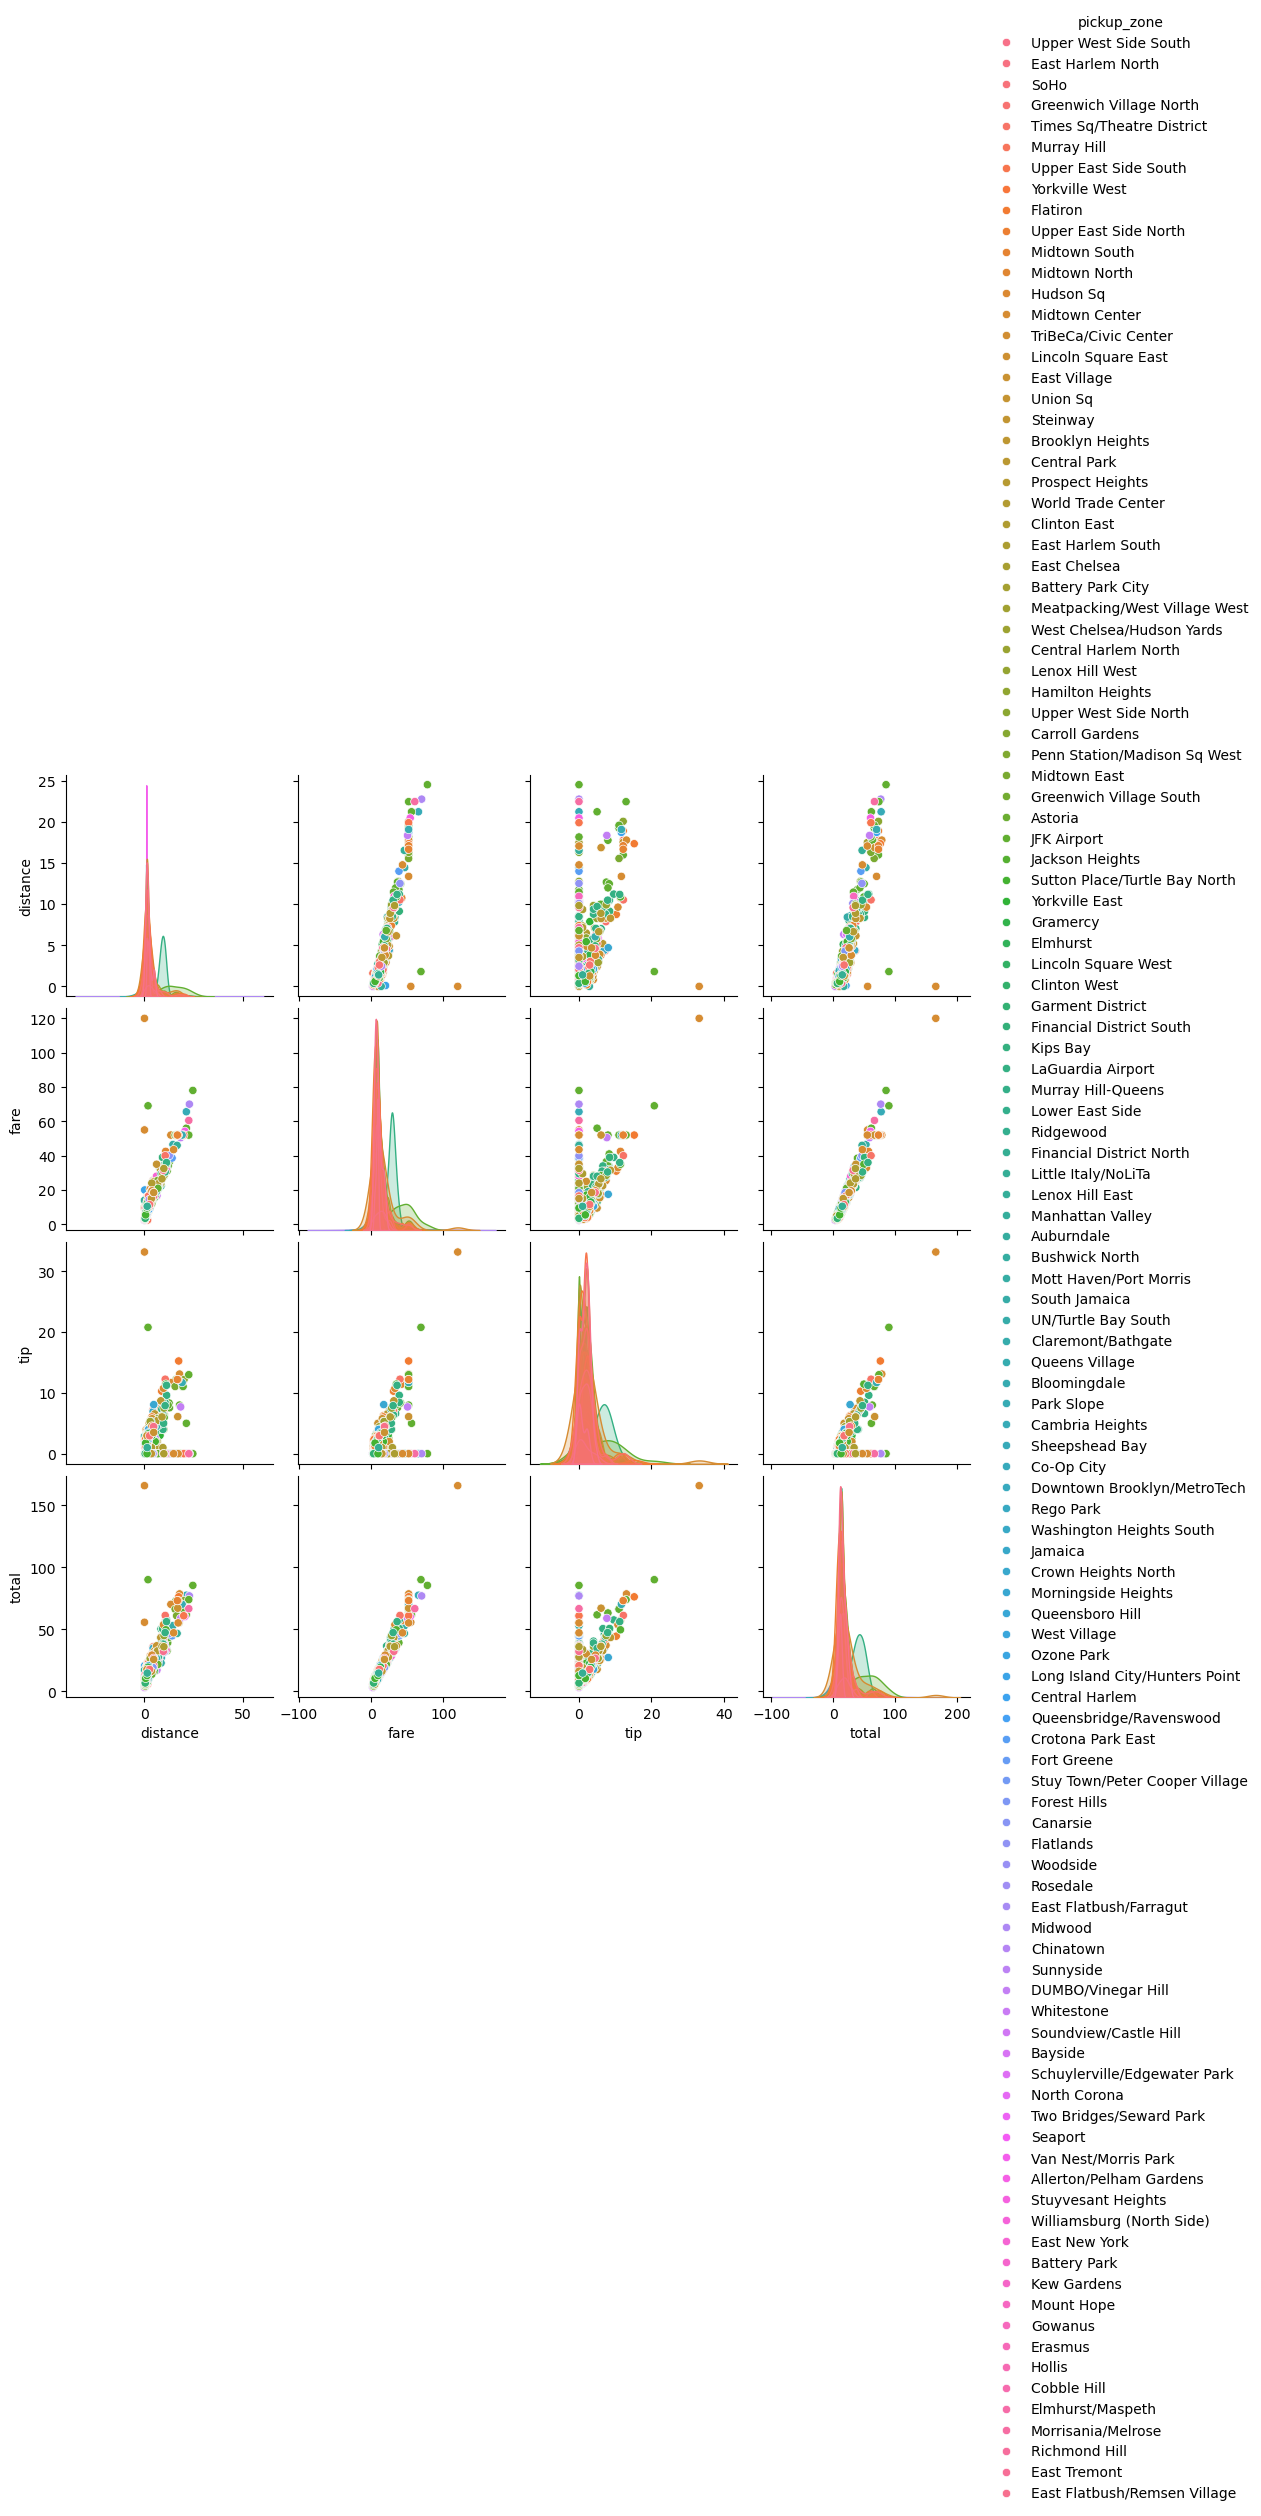

In [23]:
# ★ Pair Plot

sns.pairplot(
    pair_df,
    vars=["distance", "fare", "tip", "total"],
    hue="pickup_zone"
)

plt.show()

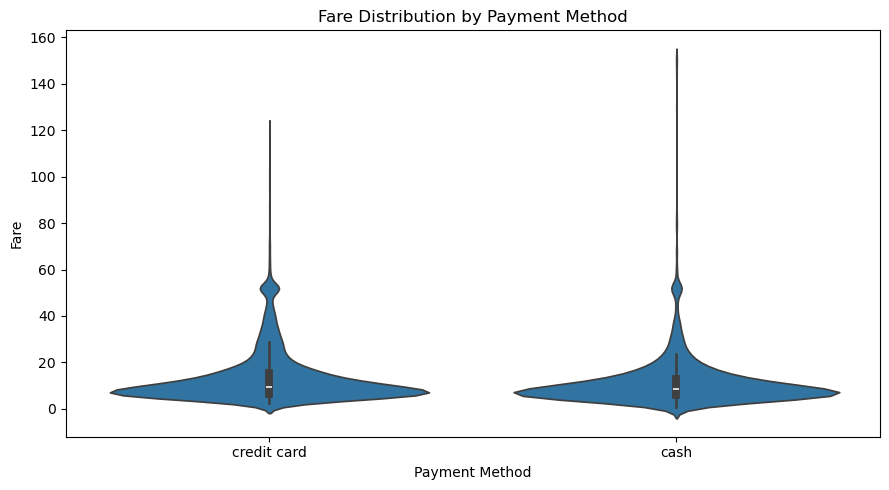

In [24]:
# ★ Violin Plot

plt.figure(figsize=(9, 5))

sns.violinplot(
    data=df,
    x="payment",
    y="fare"
)

plt.title("Fare Distribution by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Fare")

plt.tight_layout()
plt.show()

In [25]:
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [26]:
df.isnull().sum()

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6433 non-null   object        
 10  pickup_zone      6433 non-null   object        
 11  dropoff_zone     6433 non-null   object        
 12  pickup_borough   6433 non-null   object        
 13  dropoff_borough  6433 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(